# Lab 14: GAN

In this lab, we will implement a **Deep Convolutional Generative Adversarial Network (DCGAN)** to generate realistic human face images using the **CelebA** dataset. DCGANs are a popular subclass of GANs that leverage convolutional layers in both the generator and the discriminator to stabilize training and improve the quality of generated outputs.

By the end of this lab, you will:
- Understand the architecture and intuition behind DCGANs
- Implement the generator and discriminator using convolutional layers
- Train your DCGAN on the CelebA dataset
- Visualize generated face images during training

TAs : En Zheng (enzheng@andrew.cmu.edu) & Miya Sylvester（nsylvest@andrew.cmu.edu）

From lecture slides:

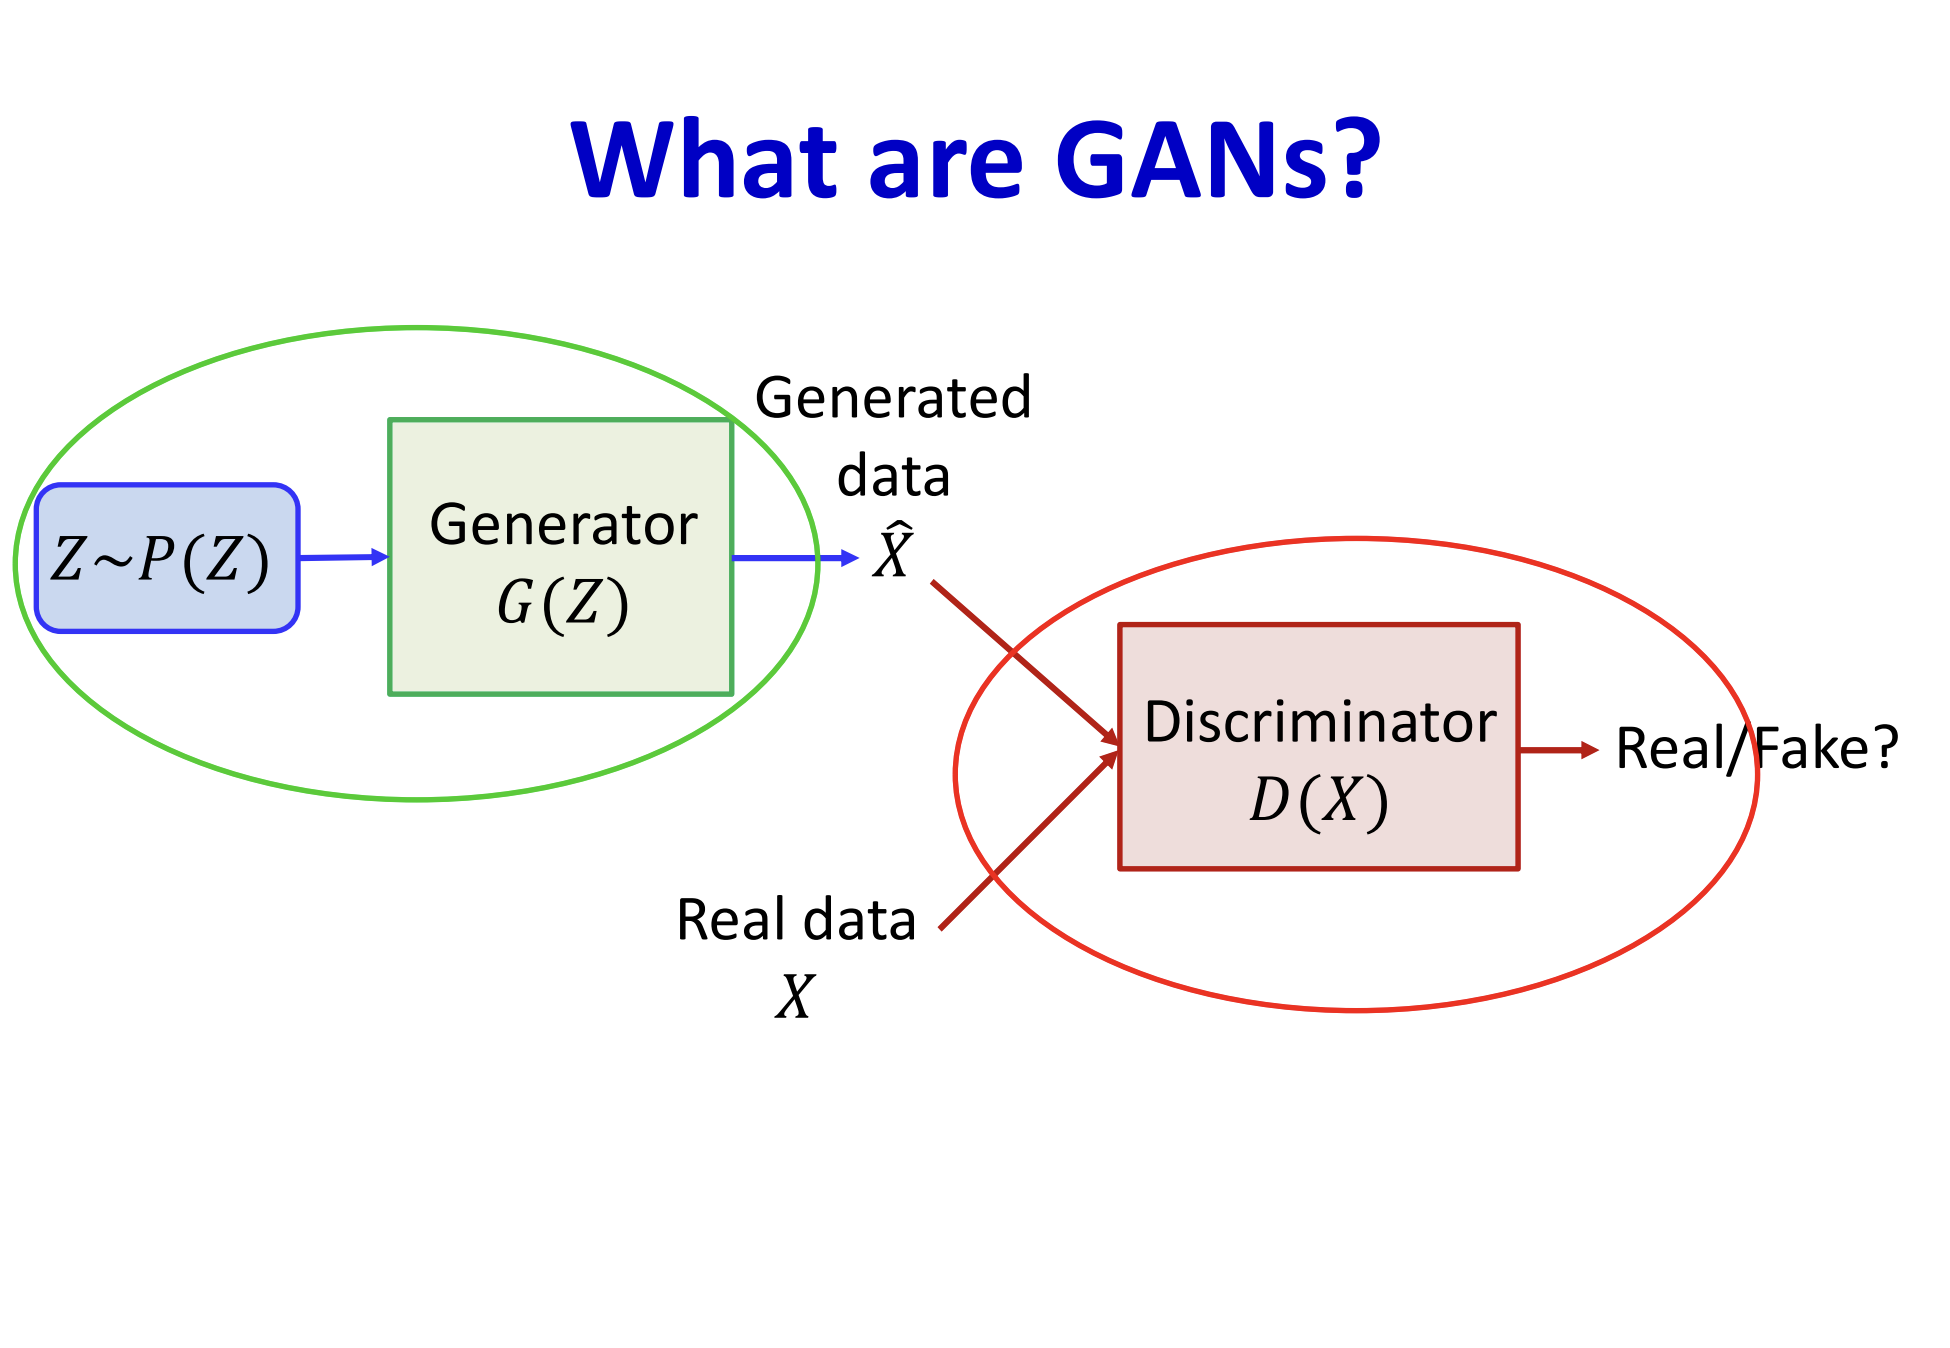



Generative Adversarial Networks (GANs), introduced by Ian Goodfellow in 2014, are a class of deep learning models where two neural networks — a **generator** and a **discriminator** — are trained simultaneously in a competitive setting.

- The **generator** tries to produce realistic data (like images) from random noise.
- The **discriminator** tries to distinguish between real data (from the dataset) and fake data (from the generator).

This creates a minimax game between the two networks:
- The generator improves by learning to fool the discriminator.
- The discriminator improves by getting better at spotting fake samples.

Over time, the generator learns to produce increasingly realistic outputs that closely resemble the training data. GANs have been used to generate images, music, text, and even 3D shapes.

ref paper: https://arxiv.org/abs/1406.2661

In this lab, we will focus on a **DCGAN** — a GAN that uses deep convolutional layers in both the generator and discriminator — to generate realistic human faces from the CelebA dataset.


## Deep Convolutional Generative Adversarial Networks

reference paper: https://arxiv.org/abs/1511.06434

In [ ]:

# !pip install torch torchvision matplotlib       # Install required packages (uncomment if not in Colab)

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
import random
import argparse
import os
import torch.nn.parallel
import torch.utils.data
import torchvision.datasets as dset
import torchvision.utils as vutils
import matplotlib.animation as animation
from IPython.display import HTML


manualSeed = 42
random.seed(manualSeed)
torch.manual_seed(manualSeed)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
torch.use_deterministic_algorithms(True)

### Download Dataset
The dataset can be downloaded from;\
https://drive.google.com/file/d/0B7EVK8r0v71pZjFTYXZWM3FlRnM/view?usp=drive_link&resourcekey=0-dYn9z10tMJOBAkviAcfdyQ

Once downloaded, create a directory named `celeba` and extract the zip file into that directory. Then, set the dataroot input for this notebook to the `celeba` directory you just created

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Unzip and extract the dataset
specify the location of the downloaded zip file of the data as well as the location where you want to store the extracted files.

!unzip /path/to/file.zip -d /path/to/data/dir/

In [ ]:
!unzip /content/drive/MyDrive/Lab14/img_align_celeba.zip -d /content/celeba

## Some Useful Variables

In [ ]:
# Root directory for dataset
dataroot = "/content/celeba"

# Number of workers for dataloader
workers = 2

# Batch size during training
batch_size = 128

# Spatial size of training images. All images will be resized to this
#   size using a transformer.
image_size = 64

# Number of channels in the training images. For color images this is 3
nc = 3

# Size of z latent vector (i.e. size of generator input)
nz = 100

# Size of feature maps in generator
ngf = 128

# Size of feature maps in discriminator
ndf = 128

# Number of training epochs
num_epochs = 5

# Learning rate for optimizers
lr = 0.0002

# Beta1 hyperparameter for Adam optimizers
beta1 = 0.5

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

## Dataset and Dataloader

### Apply transformations to images (resize, crop, normalize) and load the dataset using a DataLoader for batching.

In [ ]:
# We can use an image folder dataset the way we have it setup.
# Create the dataset
dataset = dset.ImageFolder(root=dataroot,
                           transform=transforms.Compose([
                               #### Checkpoint 1 #####
                               # TODO: Add transforms to Resize and Crop
                               
                               #### Checkpoint 2 #####
                               # TODO: Add transform to Normalize
                               
                           ]))
# Create the dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)

# Decide which device we want to run on
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")

# Plot some training images
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

## Weight Initialization

In [ ]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# DCGAN Generator

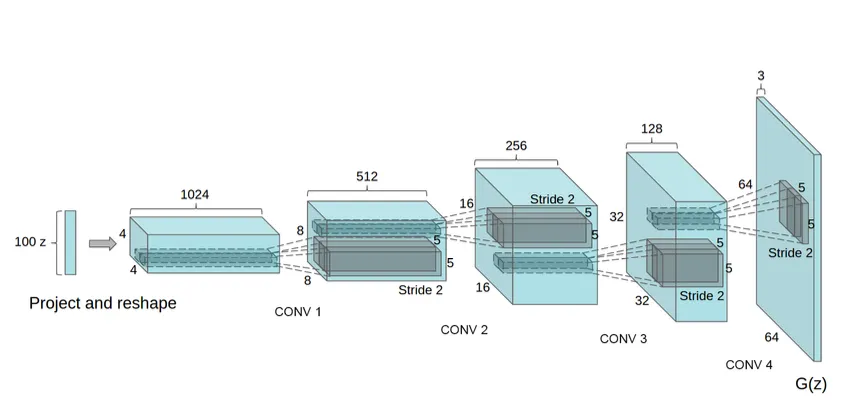

## Generator

### Define the Generator network using transposed convolutions to upsample from a latent vector to a 64x64 image.

In [ ]:
# Generator Code

class Generator(nn.Module):
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            ### Checkpoint 3 ###
            # TODO: Add the first conv layer with z as input (Hint: refer to the generator diagram above)
            
            # state size. ``(ngf*8) x 4 x 4``
            
            # state size. ``(ngf*4) x 8 x 8``
            
            # state size. ``(ngf*2) x 16 x 16``
            
            ### Checkpoint 4 ###
            # TODO: Add the last conv layer (Hint: refer to the generator diagram above)
            # state size. ``(ngf) x 32 x 32``
            
            # state size. ``(nc) x 64 x 64``
        )

    def forward(self, input):
        return self.main(input)

### Instantiate the generator

In [ ]:
# Create the generator
netG = Generator(ngpu).to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
#  to ``mean=0``, ``stdev=0.02``.
netG.apply(weights_init)

# Print the model
print(netG)

## Discriminator

### Define the Discriminator network using strided convolutions to classify 64x64 images as real or fake.

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, ngpu):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            ### Checkpoint 5 ###
            # TODO: Add the first conv layer (Hint: refer to values in the config for input dimension)
            # input is ``(nc) x 64 x 64``
            
            # state size. ``(ndf) x 32 x 32``
            
            # state size. ``(ndf*2) x 16 x 16``
            
            # state size. ``(ndf*4) x 8 x 8``
            
            ### Checkpoint 6 ###
            # TODO: Add the last conv layer for the discriminator
            # state size. ``(ndf*8) x 4 x 4``
            
        )

    def forward(self, input):
        return self.main(input)

### Instantiate the Discriminator

In [ ]:
# Create the Discriminator
netD = Discriminator(ngpu).to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netD = nn.DataParallel(netD, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
# like this: ``to mean=0, stdev=0.2``.
netD.apply(weights_init)

# Print the model
print(netD)

## Loss Functions and Optimizers

### Set up Binary Cross-Entropy (BCE) loss function and define separate Adam optimizers for both Generator and Discriminator.

In [ ]:
# Initialize the ``BCELoss`` function
criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
#  the progression of the generator
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Establish convention for real and fake labels during training
real_label = 1.
fake_label = 0.

### Checkpoint 7 ###
# TODO: Setup Adam optimizers for both G and D


## Training

Expected runtime for 5 epochs (Colab T4: 25mins)

### Implement the core GAN training process:
*   Train Discriminator with real and fake images.
*   Train Generator to fool the Discriminator.
*   Log losses and save generated images periodically.


In [ ]:
# Training Loop

# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")
# For each epoch
for epoch in range(num_epochs):
    # For each batch in the dataloader
    for i, data in enumerate(dataloader, 0):

        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        ## Train with all-real batch
        netD.zero_grad()
        # Format batch
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        # Forward pass real batch through D
        output = netD(real_cpu).view(-1)
        # Calculate loss on all-real batch
        errD_real = criterion(output, label)
        # Calculate gradients for D in backward pass
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate batch of latent vectors
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        # Generate fake image batch with G
        fake = netG(noise)
        label.fill_(fake_label)
        # Classify all fake batch with D
        output = netD(fake.detach()).view(-1)
        ### Checkpoint 8 ###
        # TODO: Calculate D's loss on the all-fake batch
        
        # Calculate the gradients for this batch, accumulated (summed) with previous gradients
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        ### Checkpoint 9 ###
        # TODO: Compute error of D as sum over the fake and the real batches
       
        # Update D
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ###########################
        netG.zero_grad()
        label.fill_(real_label)  # fake labels are real for generator cost
        # Since we just updated D, perform another forward pass of all-fake batch through D
        output = netD(fake).view(-1)
        ### Checkpoint 10 ###
        # TODO: Calculate G's loss based on this output
        
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, len(dataloader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check how the generator is doing by saving G's output on fixed_noise
        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

## Results

### Loss versus training iteration

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Visualization of G's progression

In [ ]:
fig = plt.figure(figsize=(8,8))
plt.axis("off")
ims = [[plt.imshow(np.transpose(i,(1,2,0)), animated=True)] for i in img_list]
ani = animation.ArtistAnimation(fig, ims, interval=1000, repeat_delay=1000, blit=True)

HTML(ani.to_jshtml())

### Real Images vs. Fake Images

In [ ]:
# Grab a batch of real images from the dataloader
real_batch = next(iter(dataloader))

# Plot the real images
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=5, normalize=True).cpu(),(1,2,0)))

# Plot the fake images from the last epoch
plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))
plt.show()